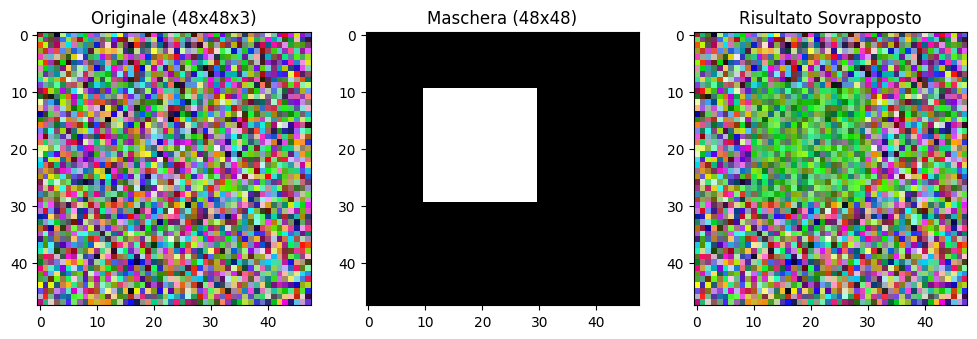

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_mask(image, mask, color=[255, 0, 0], alpha=0.5):
    """
    Sovrappone una maschera binaria a un'immagine a colori.
    
    Args:
        image: Array 48x48x3 (uint8)
        mask: Array 48x48 (booleano o 0/1)
        color: Lista RGB del colore della sovrapposizione (default Rosso)
        alpha: Intensità della sovrapposizione (0.0 a 1.0)
    """
    # Creiamo una copia per non modificare l'originale
    overlay = image.copy().astype(float)
    
    # Creiamo un'immagine colorata basata sulla maschera
    # Se mask è 1 (True), applichiamo il colore scelto
    colored_mask = np.zeros_like(image, dtype=float)
    colored_mask[mask > 0] = color
    
    # Applichiamo la formula del blending: (1-alpha)*Originale + alpha*Colore
    # Solo dove la maschera è attiva
    mask_indices = mask > 0
    overlay[mask_indices] = (1 - alpha) * image[mask_indices] + alpha * np.array(color)
    
    return overlay.astype(np.uint8)

# --- Esempio di Utilizzo ---

# 1. Creiamo dati fittizi (sostituisci con le tue immagini)
img_dummy = np.random.randint(0, 255, (48, 48, 3), dtype=np.uint8)
mask_dummy = np.zeros((48, 48))
mask_dummy[10:30, 10:30] = 1  # Un quadrato bianco al centro

# 2. Generiamo l'overlay
result = overlay_mask(img_dummy, mask_dummy, color=[0, 255, 0], alpha=0.4) # Overlay Verde

# 3. Visualizzazione
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_dummy)
ax[0].set_title("Originale (48x48x3)")
ax[1].imshow(mask_dummy, cmap='gray')
ax[1].set_title("Maschera (48x48)")
ax[2].imshow(result)
ax[2].set_title("Risultato Sovrapposto")
plt.show()

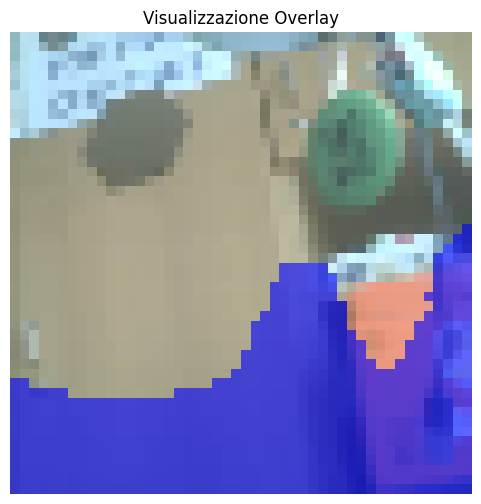

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def overlay_mask(image, mask, color=[255, 0, 0], alpha=0.5):
    overlay = image.copy().astype(float)
    # Assicuriamoci che la maschera sia binaria (0 o 1)
    mask_binary = (mask > 127).astype(np.uint8) 
    
    mask_indices = mask_binary > 0
    overlay[mask_indices] = (1 - alpha) * image[mask_indices] + alpha * np.array(color)
    return overlay.astype(np.uint8)

# 1. Percorsi dei file (Sostituisci i nomi dei file qui!)
num = 4
path_img = os.path.join("img", f"{num}_RGB_SMALL.bmp")
path_mask = os.path.join("img", f"{num}depth_map.bmp")

# 2. Caricamento
# Carichiamo l'immagine a colori e la convertiamo da BGR a RGB
img_rgb = cv2.imread(path_img)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

# Carichiamo la maschera in scala di grigi (0)
mask_gray = cv2.imread(path_mask, 0) 

# 3. Ridimensionamento (Opzionale ma consigliato se non sei sicuro siano 48x48)
img_rgb = cv2.resize(img_rgb, (48, 48))
mask_gray = cv2.resize(mask_gray, (48, 48))

# 4. Applicazione dell'overlay
# Usiamo un bel blu [0, 0, 255] per evidenziare la maschera
risultato = overlay_mask(img_rgb, mask_gray, color=[0, 0, 255], alpha=0.6)

# 5. Visualizzazione
plt.figure(figsize=(6, 6))
plt.imshow(risultato)
plt.axis('off')
plt.title("Visualizzazione Overlay")
plt.show()

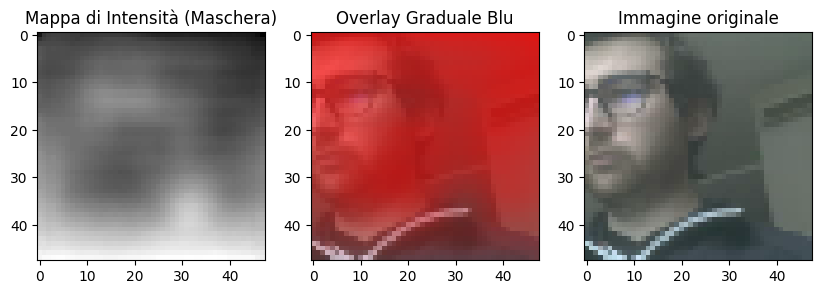

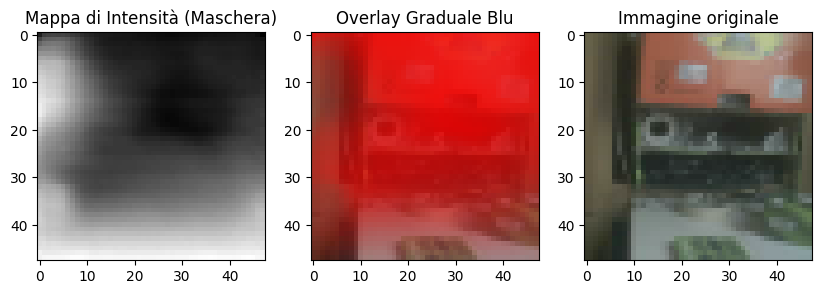

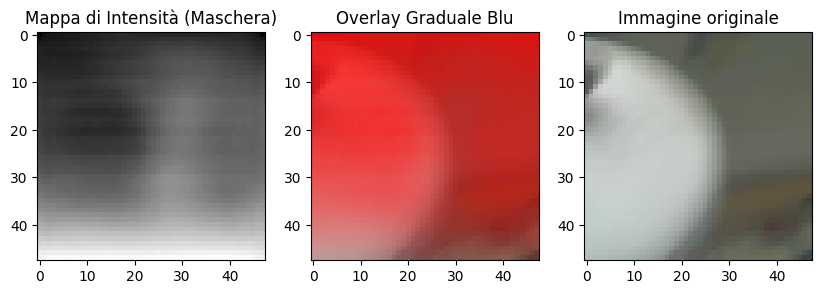

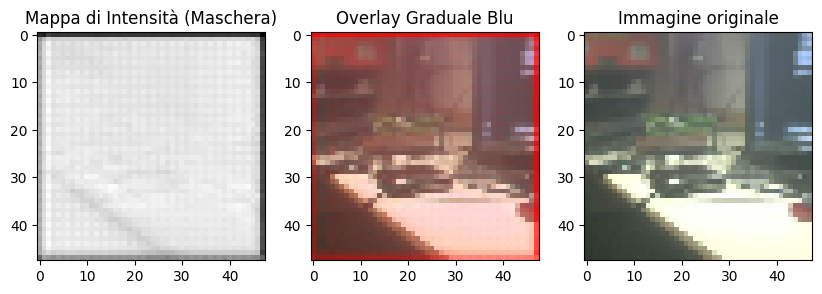

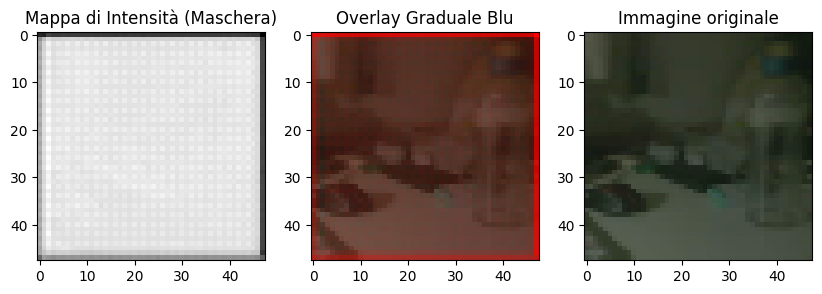

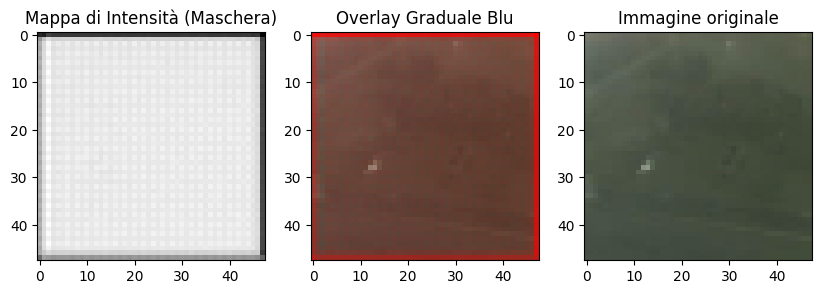

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def apply_weighted_overlay(image, mask, color=[0, 0, 255]):
    """
    Applica un colore basandosi sull'intensità della maschera (0-255).
    """
    # 1. Convertiamo l'immagine in float per i calcoli
    img_float = image.astype(float)
    
    # 2. Normalizziamo la maschera tra 0.0 e 1.0 (diventa il nostro alpha locale)
    # alpha_map sarà un array 48x48
    alpha_map = mask.astype(float) / 255.0
    
    # 3. Prepariamo il risultato
    result = np.zeros_like(img_float)
    
    # 4. Applichiamo la formula pixel per pixel (vettorizzata)
    # Per ogni canale (R, G, B): (1 - alpha) * Immagine + alpha * Colore_Target
    for i in range(3):
        result[:, :, i] = (1.0 - alpha_map) * img_float[:, :, i] + alpha_map * color[i]
        
    return result.astype(np.uint8)

dir_path = "i"

# --- Caricamento ---
amount = len(os.listdir(dir_path)) // 4
# num = 8
for num in range(0, amount * 4, 4):
    path_img = os.path.join(dir_path, f"{num}_RGB_SMALL.bmp")
    # Assicurati che il nome sia corretto (es. "0depth_map.bmp" o "0_depth_map.bmp")
    path_mask = os.path.join(dir_path, f"{num}depth_map.bmp") 

    img_bgr = cv2.imread(path_img)
    mask_gray = cv2.imread(path_mask, 0)

    if img_bgr is not None and mask_gray is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Ridimensionamento
        img_rgb = cv2.resize(img_rgb, (48, 48))
        mask_gray = cv2.resize(mask_gray, (48, 48))

        # Applichiamo l'overlay pesato
        # Qui usiamo il BLU [0, 0, 255]
        risultato = apply_weighted_overlay(img_rgb, 255-mask_gray, color=[255, 0, 0])

        # Visualizzazione
        fig, ax = plt.subplots(1, 3, figsize=(10, 5))
        ax[0].imshow(mask_gray, cmap='gray')
        ax[0].set_title("Mappa di Intensità (Maschera)")
        ax[1].imshow(risultato)
        ax[1].set_title("Overlay Graduale Blu")
        ax[2].imshow(img_rgb)
        ax[2].set_title("Immagine originale")
        plt.show()
    else:
        print("Controlla i percorsi dei file, uno dei due non è stato caricato.")

In [19]:
os.listdir("img")

['0.jpg',
 '0depth_map.bmp',
 '0_RGB.bmp',
 '0_RGB_SMALL.bmp',
 '4.jpg',
 '4depth_map.bmp',
 '4_RGB.bmp',
 '4_RGB_SMALL.bmp',
 '8.jpg',
 '8depth_map.bmp',
 '8_RGB.bmp',
 '8_RGB_SMALL.bmp']